In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.quantum_info.operators import Operator
from qiskit.visualization import plot_histogram
from numpy import pi, cos, sin, linspace
import matplotlib.pyplot as plt

Make the Hadamarg gate with the state $\ket{\psi_\theta}=\cos\theta\ket{0}+\sin\theta\ket{1}$

In [ ]:
# make the state |psi_theta>=cos(theta)|0>+sin(theta)|1>
psi1 = Statevector([cos(pi/8), sin(pi/8)])
psi2 = Statevector([cos(5*pi/8), sin(5*pi/8)])

# to create the operator we just apply the Operator function. It makes the outer product
H = Operator(psi1) - Operator(psi2) # hadamard gate
display(H.draw('latex'))

<IPython.core.display.Latex object>

We implement the phase kick-back phenomenon with low precision

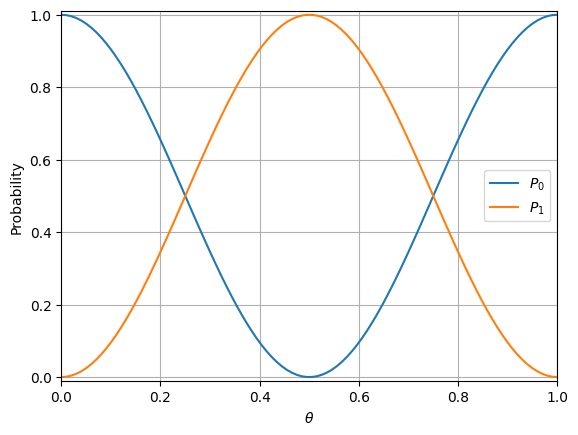

In [22]:
# make the graph of theta and the probability
values = linspace(0,1,100)
p0 = [cos(pi*theta)**2 for theta in values]
p1 = [sin(pi*theta)**2 for theta in values]

fig, ax = plt.subplots()

ax.plot(values, p0, lw=1.5, label='$P_0$')
ax.plot(values, p1, lw=1.5, label='$P_1$')
ax.set_xlabel('$\\theta$')
ax.set_ylabel('Probability')
ax.set_xlim([0,1])
ax.set_ylim([-0.01,1.01])
ax.legend()
ax.grid()

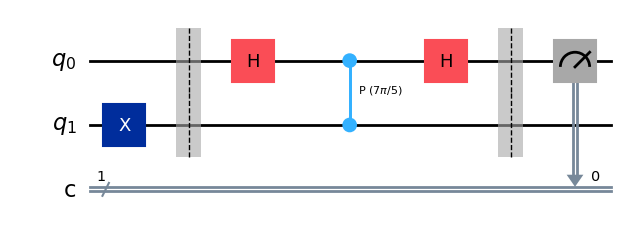

In [18]:
theta = 0.7 # any value [0,1)

# create the quantum circuit
qc = QuantumCircuit(2, 1)

# prepare the eigenvector in |1>
qc.x(1)
qc.barrier()

# implement the procedure
qc.h(0)
qc.cp(2*pi*theta, control_qubit=0, target_qubit=1)
qc.h(0)
qc.barrier()

# measurement
qc.measure(qubit=0, cbit=0)

# draw circuit
display(qc.draw(output='mpl'))

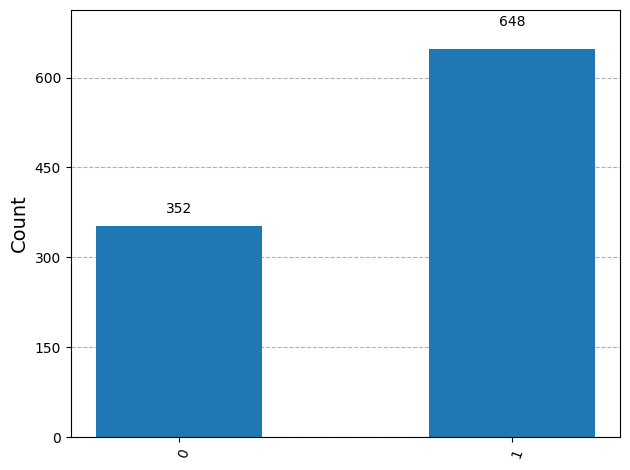

P0=cos(pi * 0.7)**2 = 0.3455
P1=sin(pi * 0.7)**2 = 0.6545


In [21]:
# simulate the circuit
result     = AerSimulator().run(qc, shots=1000).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

# probabilities
print(f"P0=cos(pi * {theta})**2 = {cos(pi * theta) ** 2:.4f}")
print(f"P1=sin(pi * {theta})**2 = {sin(pi * theta) ** 2:.4f}")

If we double the pase, that is, add other controlled-U gate. With this, we increase the information of $\theta$, because now we know more values to obtain the desire result

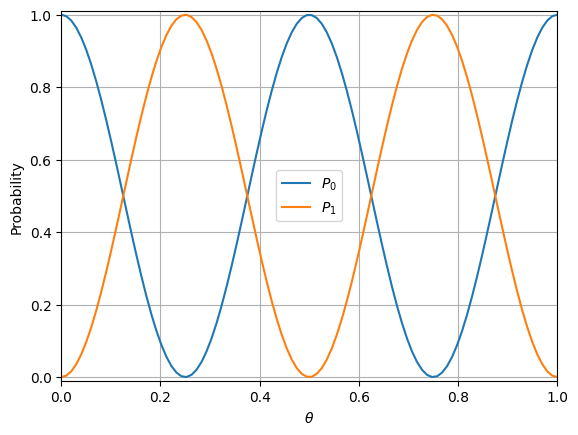

In [23]:
# make the graph of theta and the probability
values = linspace(0,1,100)
p0 = [cos(2*pi*theta)**2 for theta in values]
p1 = [sin(2*pi*theta)**2 for theta in values]

fig, ax = plt.subplots()

ax.plot(values, p0, lw=1.5, label='$P_0$')
ax.plot(values, p1, lw=1.5, label='$P_1$')
ax.set_xlabel('$\\theta$')
ax.set_ylabel('Probability')
ax.set_xlim([0,1])
ax.set_ylim([-0.01,1.01])
ax.legend()
ax.grid()

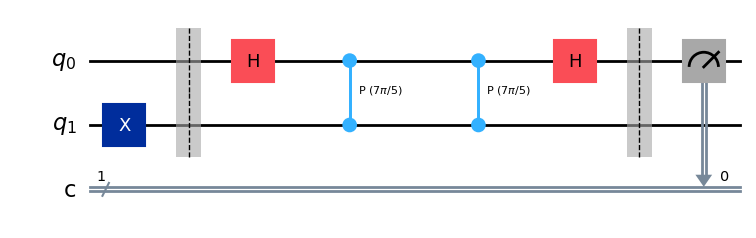

In [25]:
theta = 0.7 # any value [0,1)

# create the quantum circuit
qc = QuantumCircuit(2, 1)

# prepare the eigenvector in |1>
qc.x(1)
qc.barrier()

# implement the procedure
qc.h(0)
qc.cp(2*pi*theta, control_qubit=0, target_qubit=1)
qc.cp(2*pi*theta, control_qubit=0, target_qubit=1)
qc.h(0)
qc.barrier()

# measurement
qc.measure(qubit=0, cbit=0)

# draw circuit
display(qc.draw(output='mpl'))

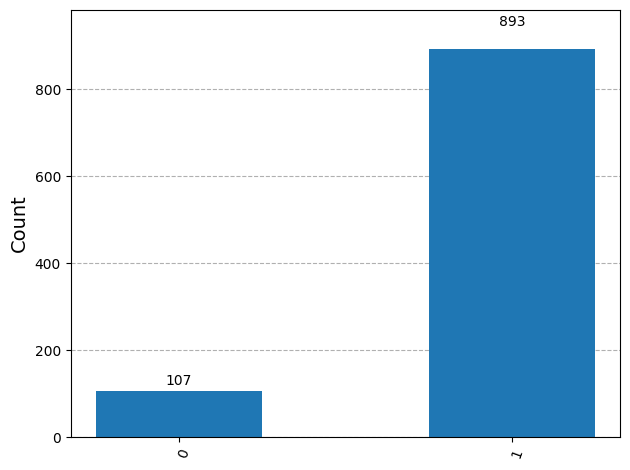

P0=cos(2*pi * 0.7)**2 = 0.0955
P1=sin(2*pi * 0.7)**2 = 0.9045


In [26]:
# simulate the circuit
result     = AerSimulator().run(qc, shots=1000).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

# probabilities
print(f"P0=cos(2*pi * {theta})**2 = {cos(2*pi * theta) ** 2:.4f}")
print(f"P1=sin(2*pi * {theta})**2 = {sin(2*pi * theta) ** 2:.4f}")

We can add more control qubits and combine techniques

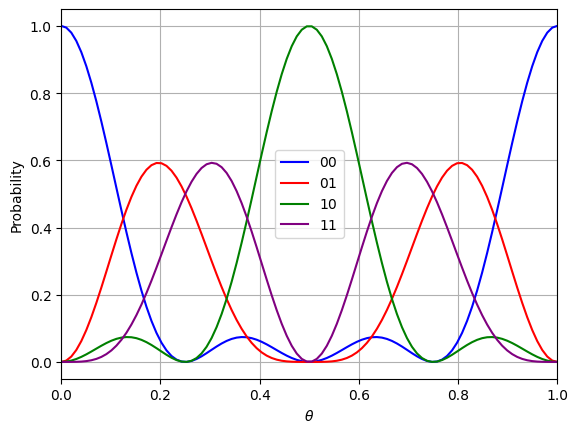

In [52]:
# values of the probability
values = linspace(0,1,100)
p00 = [(cos(pi*theta)**2 * cos(2*pi*theta)**2) for theta in values]
p01 = [cos(pi*theta)**2 * sin(2*pi*theta)**2 for theta in values]
p10 = [cos(2*pi*theta)**2 * sin(pi*theta)**2 for theta in values]
p11 = [(sin(pi*theta)**2 * sin(2*pi*theta)**2) for theta in values]




# plot
fig, ax = plt.subplots()

ax.plot(values, p00, lw=1.5, color='blue', label='$00$')
ax.plot(values, p01, lw=1.5, color='red', label='$01$')
ax.plot(values, p10, lw=1.5, color='green', label='$10$')
ax.plot(values, p11, lw=1.5, color='purple', label='$11$')
ax.set_xlabel('$\\theta$')
ax.set_ylabel('Probability')
ax.set_xlim([0,1])
#ax.set_ylim([-0.01,1.01])
ax.legend()
ax.grid()

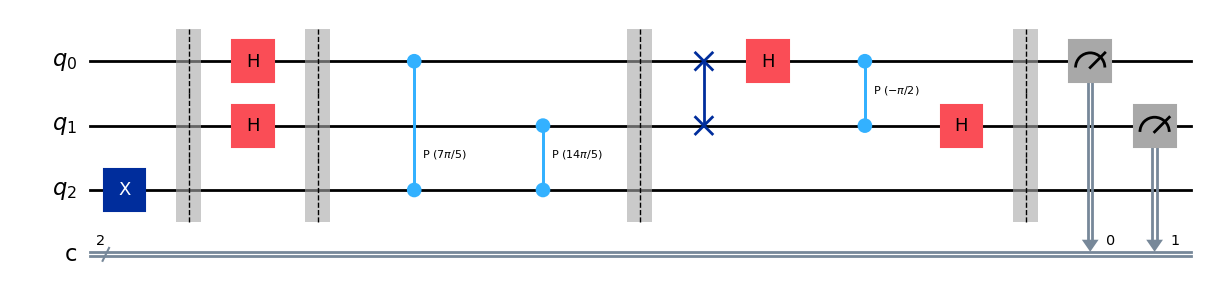

In [58]:
theta = 0.7

# create quantum circuit
qc = QuantumCircuit(3, 2)

# prepare the eigenvetor
qc.x(2)
qc.barrier()

# initial Hadamard gates
qc.h(0)
qc.h(1)
qc.barrier()

# controlled-U gates
qc.cp(2*pi*theta, control_qubit=0, target_qubit=2)
qc.cp(2*pi*(2*theta), control_qubit=1, target_qubit=2)
qc.barrier()

# implementation of the inverse of the two qubit QFT gate
qc.swap(qubit1=0, qubit2=1)
qc.h(0)
qc.cp(-pi/2, control_qubit=0, target_qubit=1)
qc.h(1)
qc.barrier()

# measurements
qc.measure(qubit=[0, 1], cbit=[0, 1])

# draw
display(qc.draw(output='mpl'))

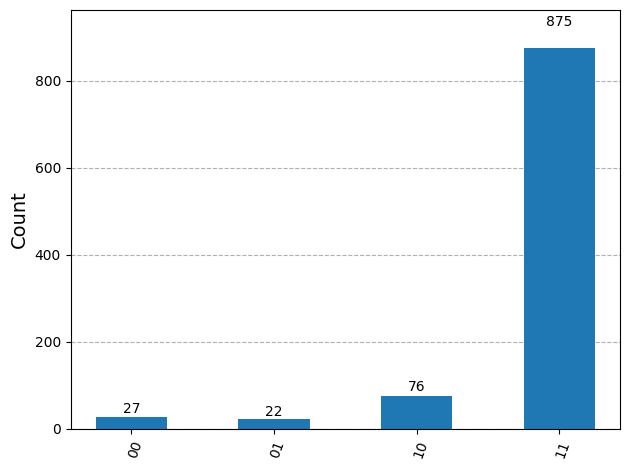

In [59]:
# run the circuit
result     = AerSimulator().run(qc, shots=1000).result()
statistics = result.get_counts()

# plot
display(plot_histogram(statistics))